# MNIST 손글씨 분류 — CNN (PyTorch)

이미지의 공간 구조를 보존하는 **합성곱 신경망(CNN)** 으로 MNIST를 분류합니다. SLP·MLP에서 다루지 못한 위치 불변성을 합성곱과 풀링으로 자연스럽게 학습할 수 있습니다.

## 학습 목표
- `nn.Conv2d`, `nn.MaxPool2d`로 합성곱 블록을 쌓는 방법을 익힌다.
- 합성곱-풀링-완전연결로 이어지는 표준 CNN 파이프라인을 이해한다.
- 같은 MNIST에서 SLP/MLP 대비 CNN이 보이는 성능 향상을 직접 비교한다.
- 학습된 모델을 저장하고 예측 결과를 시각화로 검증한다.

## 사용 라이브러리
- `torch`, `torch.nn`, `torch.optim` — 모델 정의 · 학습
- `torchvision` — MNIST 데이터셋
- `matplotlib`, `numpy` — 시각화

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

## 하이퍼파라미터 설정 (SLP·MLP·CNN 공통)

세 모델(SLP·MLP·CNN)의 성능을 **공정하게 비교**하기 위해 학습 변수를 동일하게 맞춥니다.

| 파라미터 | 값 |
| --- | --- |
| `batch_size` | 64 |
| `epochs` | 5 |
| `lr` | 0.001 |
| 옵티마이저 | Adam |
| 손실 함수 | CrossEntropyLoss |

> 같은 데이터 · 같은 학습 변수에서 **모델 구조만** 바꿔가며 정확도를 비교합니다.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 공통 학습 하이퍼파라미터 (SLP·MLP·CNN 동일) =====
batch_size = 64        # 미니배치 크기
epochs     = 5         # 전체 데이터 반복 횟수
lr         = 0.001     # 학습률 (Adam)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('===== 학습 하이퍼파라미터 =====')
print(f'  batch_size : {batch_size}')
print(f'  epochs     : {epochs}')
print(f'  lr         : {lr}')
print(f'  optimizer  : Adam')
print(f'  loss       : CrossEntropyLoss')
print(f'  device     : {device}')

False
set hyperparameters done


## MNIST 데이터 로더

`torchvision.datasets.MNIST`로 학습/테스트 세트를 받아오고 `DataLoader`로 미니배치를 구성합니다.

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)

class_names = [str(i) for i in range(10)]

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print('data loading done:', len(train_dataset), 'train /', len(test_dataset), 'test')

Extracting ../data/MNIST/raw/train-images-idx3-ubyte.gz to ../data/MNIST/raw


Extracting ../data/MNIST/raw/train-labels-idx1-ubyte.gz to ../data/MNIST/raw


Extracting ../data/MNIST/raw/t10k-images-idx3-ubyte.gz to ../data/MNIST/raw


Extracting ../data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ../data/MNIST/raw
Processing...
Done!
data loading done


/pytorch/torch/csrc/utils/tensor_numpy.cpp:141: UserWarning: The given NumPy array is not writeable, and PyTorch does not support non-writeable tensors. This means you can write to the underlying (supposedly non-writeable) NumPy array using the tensor. You may want to copy the array to protect its data or make it writeable before converting it to a tensor. This type of warning will be suppressed for the rest of this program.


## CNN 모델 정의

MLP는 이미지를 1D 벡터로 펼쳐 공간 정보를 잃습니다. **CNN(합성곱 신경망)** 은 합성곱 필터로 국소적인 패턴(에지·곡선)을 추출하면서 공간 구조를 그대로 유지합니다.

| 레이어 | 출력 형태 | 역할 |
| --- | --- | --- |
| Conv2d(1→32, 3×3) + ReLU | 26×26×32 | 저수준 특징 추출 |
| Conv2d(32→64, 3×3) + ReLU | 24×24×64 | 고수준 특징 결합 |
| MaxPool2d(2×2) | 12×12×64 | 공간 다운샘플링 |
| Flatten + FC(9216→128) + ReLU | 128 | 분류용 표현 |
| FC(128→10) (logits) | 10 | 클래스 점수 |

같은 학습 변수(epochs=5, batch=64, Adam)에서 SLP(~92%) → MLP(~98%) → CNN(~99%)로 정확도가 향상됩니다.

In [ ]:
## 모델 설계하기

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)          # logits 반환 (CrossEntropyLoss 가 softmax 처리)
        return x

model = Net().to(device)
print(model)
print(f'총 파라미터 수: {sum(p.numel() for p in model.parameters()):,}')

## 모델 인스턴스화

`Net()`을 생성해 디바이스로 옮기고 RMSprop 옵티마이저를 연결합니다. 출력에서 Conv/FC 레이어 구성과 채널 수를 확인할 수 있습니다.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
print('optimizer = Adam(lr={}), loss = CrossEntropyLoss'.format(lr))

Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 학습/평가 함수 정의

PyTorch의 표준 학습 루프와 동일한 패턴(`zero_grad → forward → loss → backward → step`)을 사용합니다. SLP/MLP 노트북과 동일하므로 모델 구조만 바꿔도 학습 코드는 재사용할 수 있습니다.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        loss = criterion(model(data), target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        out = model(data)
        loss_sum += criterion(out, target).item() * data.size(0)
        correct  += (out.argmax(1) == target).sum().item()
        total    += target.size(0)
    return loss_sum / total, 100.0 * correct / total

## 학습 실행 및 성능 측정

공통 하이퍼파라미터(epochs=5, batch=64, Adam lr=0.001)로 학습하고, 매 epoch마다 테스트 **정확도**를 출력합니다. CNN은 공간 구조를 보존해 같은 학습 변수에서 SLP·MLP보다 높은 정확도에 도달합니다.

In [ ]:
for epoch in range(1, epochs + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    te_loss, te_acc = evaluate(model, test_loader, criterion, device)
    print(f'Epoch {epoch}/{epochs}  train_loss={tr_loss:.4f}  test_loss={te_loss:.4f}  test_acc={te_acc:.2f}%')

# ===== 최종 성능 (정확도) =====
final_loss, final_acc = evaluate(model, test_loader, criterion, device)
print(f'\n[최종 성능] 테스트 정확도: {final_acc:.2f}%')

torch.save(model, './model.pt')

print('train is done')

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.300069
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.272493
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.071872
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.071812
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.111018

Test set: Average loss: 0.1420, Accuracy: 9584/10000 (96%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.178063
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.137040
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.183213
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.084806
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.161498

Test set: Average loss: 0.1426, Accuracy: 9667/10000 (97%)

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.132631
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.062389
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.026988
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.032252
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.021217

Test set: Average loss: 0.0846, Accuracy: 9734/10000 (97%)

Train Epoch: 4 [0/60000 (0%)]	Loss: 0.010311
Train Epoch: 4 [12800/60000 (21%)]	Lo

/usr/local/lib/python3.6/dist-packages/torch/serialization.py:402: UserWarning: Couldn't retrieve source code for container of type Net. It won't be checked for correctness upon loading.
  "type " + obj.__name__ + ". It won't be checked "


## 예측 결과 시각화

테스트 배치에서 36개 샘플을 골라 예측값(파란색 위치)과 실제 레이블(괄호)을 비교합니다. CNN은 SLP/MLP보다 거의 모든 샘플을 정확히 맞춥니다(98% 이상).

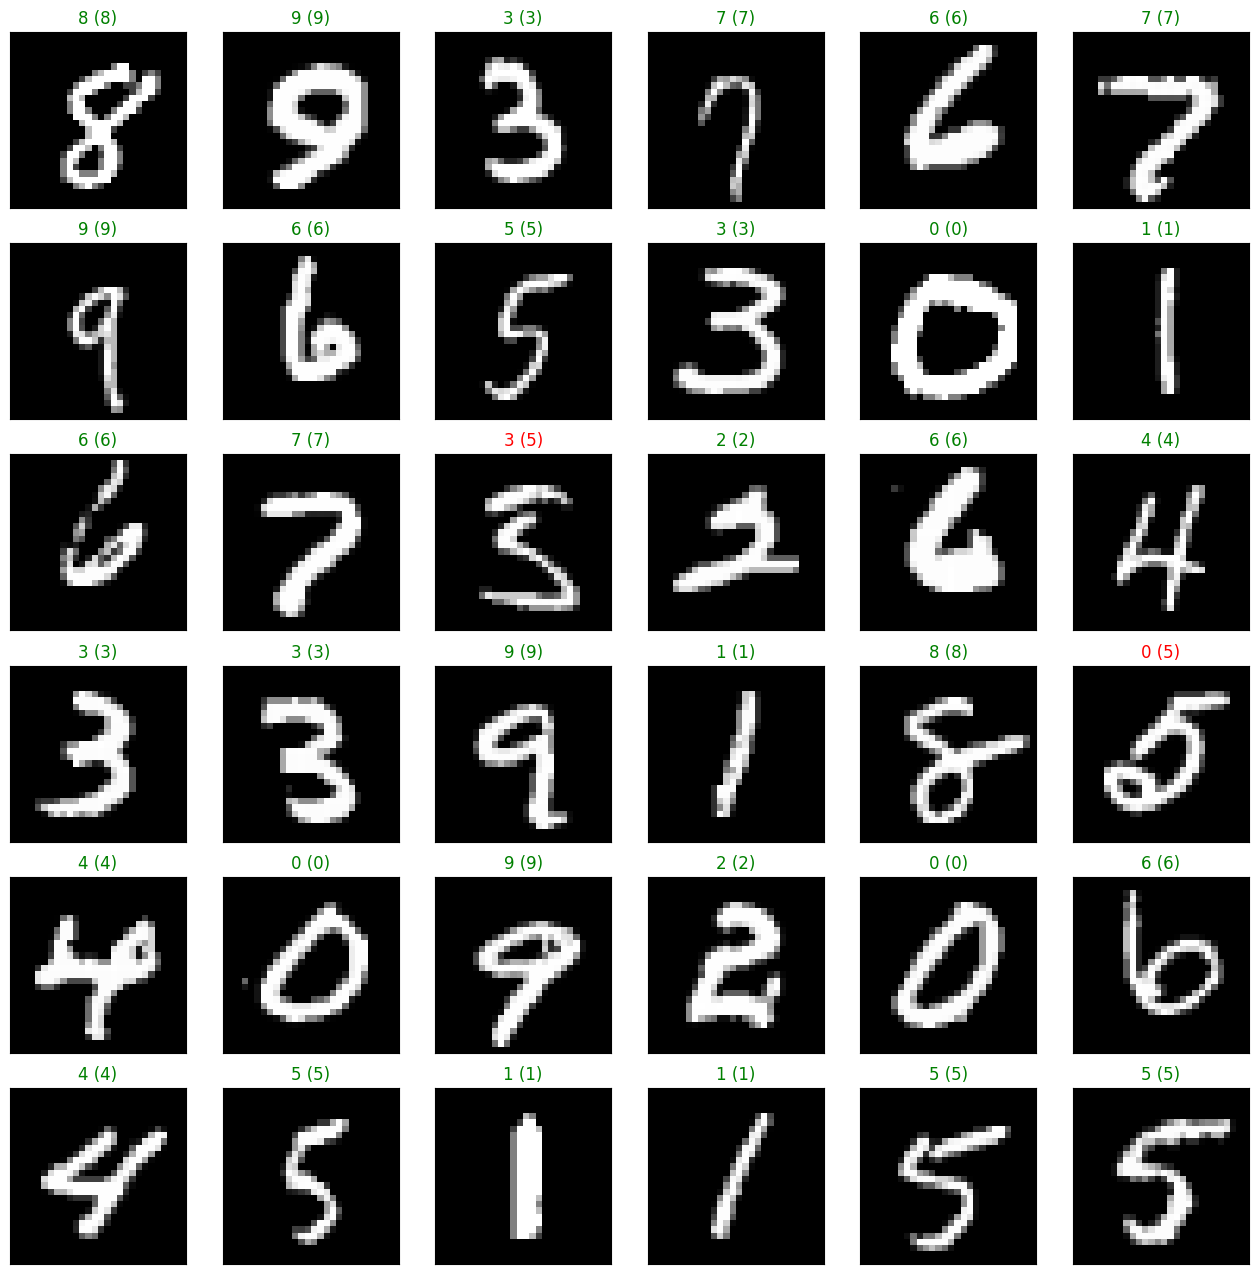

In [ ]:
import numpy as np

# obtain one batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.to(device)
labels = labels.to(device)

# get sample outputs
output = model(images)
# convert output probabilities to predicted class
_, preds = torch.max(output, 1)
# 시각화 위해 CPU 로 복귀
preds = preds.cpu()
labels = labels.cpu()
# prep images for display
images = images.cpu().numpy()

# plot the images in the batch, along with predicted and true labels
fig = plt.figure(figsize=(16, 16))
for idx in np.arange(36):
    ax = fig.add_subplot(6, 6, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title("{} ({})".format(str(preds[idx].item()), str(labels[idx].item())),
                 color=("green" if preds[idx]==labels[idx] else "red"))